In [4]:
import pandas as pd
!pip install openpyxl
!pip install odfpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from openpyxl import load_workbook
from pandas import ExcelWriter


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160672 sha256=7112ee0e0a419c8ca8408024932c5ec058dad8a5998c9e291774ff108ae979e9
  Stored in directory: /home/uib/.cache/pip/wheels/8e/cd/9f/979443982946991080916064e4c049b91941be1800825ff74b
Successfully built odfpy


In [13]:
# Function to color rows according to measure classification
def highlight_rows(row,quality_column="measure_ok_abs_max"):

    if row[quality_column]=='good':
         color = '#d9f2d9'  # soft green
    elif row[quality_column]=='medium':
        color = '#fff3cd'  # soft orange/yellow
    elif row[quality_column]=='bad':
         color = '#f8d7da'  # soft red/pink
    else:
        print("PROBLEM!!")
        color ="white"
    return [f'background-color: {color}'] * len(row)



In [48]:
df_all_fish = pd.read_excel("Info_i_resultats_experiments.ods", sheet_name="All_results",usecols="E:S", engine="odf")
df_all_fish
df_all_fish_colored = df_all_fish.style.apply(lambda row: highlight_rows(row, quality_column='MeasureOkAbs'), axis=1)
df_all_fish_colored

,CodiEscenari,day,hour,TrackId,count,FilteredLength,gt,AbsERROR [cm],Relative Error [%],MeasureOkAbs,MaxLength,MeanLength,std_dev,ElevationDeg Mean,comentaris
0,E1,2025_05_08,11_17_18,1,229,0.354954,33.500000,1.995440,5.956536,medium,0.354954,0.286838,0.046504,3.840179,nan
1,E1,2025_05_08,11_17_18,6,1,0.281012,-100.000000,128.101211,-128.101211,bad,0.281012,0.281012,nan,47.917588,És una flipada del model no un peix real
2,E1,2025_05_08,11_17_18,9,1,0.133280,-100.000000,113.327989,-113.327989,bad,0.133280,0.133280,nan,37.961841,És una flipada del model no un peix real
3,E1,2025_05_08,11_41_03,1,166,0.351634,33.500000,1.663362,4.965258,medium,0.351634,0.300984,0.019988,12.917739,nan
4,E1,2024_11_12,11_00_27,-1,2,0.310201,31.500000,0.479929,1.523584,good,0.310201,0.301163,0.012781,33.517996,nan
5,E1,2024_11_12,11_00_27,1,13,0.323248,31.500000,0.824780,2.618350,good,0.323248,0.309337,0.006559,0.268105,nan
6,E1,2024_11_12,11_00_27,2,7,0.307402,31.500000,0.759782,2.412006,good,0.307402,0.303406,0.005080,49.949135,nan
7,E1,2024_11_12,11_00_27,3,19,0.317256,31.500000,0.225608,0.716217,good,0.317256,0.292069,0.018857,31.843069,nan
8,E1,2024_11_12,11_00_27,6,6,0.293722,31.500000,2.127815,6.754967,bad,0.293722,0.275722,0.014459,-50.791957,nan
9,E1,2024_11_12,11_00_27,8,27,0.321682,31.500000,0.668159,2.121139,good,0.321682,0.306825,0.018654,31.633586,nan


In [49]:


df_no_fake_fish = pd.read_excel("Info_i_resultats_experiments.ods", sheet_name="All_results_without_fake_fish",usecols="B:P", engine="odf")




df_no_fake_fish

df_colored = df_no_fake_fish.style.apply(lambda row: highlight_rows(row, quality_column='MeasureOkAbs'), axis=1)
df_colored

,CodiEscenari,day,hour,TrackId,count,FilteredLength,gt,AbsERROR [cm],Relative Error [%],MeasureOkAbs,MaxLength,MeanLength,std_dev,ElevationDeg Mean,comentaris
0,E1,2025_05_08,11_17_18,1,229,0.354954,33.500000,1.995440,5.956536,medium,0.354954,0.286838,0.046504,3.840179,nan
1,E1,2025_05_08,11_41_03,1,166,0.351634,33.500000,1.663362,4.965258,medium,0.351634,0.300984,0.019988,12.917739,nan
2,E1,2024_11_12,11_00_27,-1,2,0.310201,31.500000,0.479929,1.523584,good,0.310201,0.301163,0.012781,33.517996,nan
3,E1,2024_11_12,11_00_27,1,13,0.323248,31.500000,0.824780,2.618350,good,0.323248,0.309337,0.006559,0.268105,nan
4,E1,2024_11_12,11_00_27,2,7,0.307402,31.500000,0.759782,2.412006,good,0.307402,0.303406,0.005080,49.949135,nan
5,E1,2024_11_12,11_00_27,3,19,0.317256,31.500000,0.225608,0.716217,good,0.317256,0.292069,0.018857,31.843069,nan
6,E1,2024_11_12,11_00_27,6,6,0.293722,31.500000,2.127815,6.754967,bad,0.293722,0.275722,0.014459,-50.791957,nan
7,E1,2024_11_12,11_00_27,8,27,0.321682,31.500000,0.668159,2.121139,good,0.321682,0.306825,0.018654,31.633586,nan
8,E1,2024_11_12,11_00_27,11,17,0.309732,31.500000,0.526822,1.672451,good,0.309732,0.280982,0.012227,19.159536,nan
9,E1,2024_11_28,13_07_38,-1,1,0.247810,28.900000,4.118966,14.252476,bad,0.247810,0.247810,nan,24.212849,nan


In [32]:
print("Sin ningún filtro de mínimo de tracking:")

media_error_abs = df_no_fake_fish["AbsERROR [cm]"].mean()
print("Media del error absoluto:", media_error_abs)

media_error_rel = abs(df_no_fake_fish["Relative Error [%]"]).mean()
print("Media del error relativo:", media_error_rel)

print("------------------------------------------------")
print("Con un mínimo de frames para considerar la medida:")

df_tracked = df_no_fake_fish[df_no_fake_fish["count"]>5]
df_tracked_color = df_tracked.style.apply(lambda row: highlight_rows(row, quality_column='MeasureOkAbs'), axis=1)

media_error_abs = df_tracked["AbsERROR [cm]"].mean()
print("Media del error absoluto:", media_error_abs)

media_error_rel = abs(df_tracked["Relative Error [%]"]).mean()
print("Media del error relativo:", media_error_rel)


df_tracked_color


Sin ningún filtro de mínimo de tracking:
Media del error absoluto: 1.4580822113626006
Media del error relativo: 5.075181353966565
------------------------------------------------
Con un mínimo de frames para considerar la medida:
Media del error absoluto: 0.974237411392055
Media del error relativo: 3.606523974135734


,CodiEscenari,day,hour,TrackId,count,FilteredLength,gt,AbsERROR [cm],Relative Error [%],MeasureOkAbs,MaxLength,MeanLength,std_dev,ElevationDeg Mean,comentaris
0,E1,2025_05_08,11_17_18,1,229,0.354954,33.500000,1.995440,5.956536,medium,0.354954,0.286838,0.046504,3.840179,nan
1,E1,2025_05_08,11_41_03,1,166,0.351634,33.500000,1.663362,4.965258,medium,0.351634,0.300984,0.019988,12.917739,nan
3,E1,2024_11_12,11_00_27,1,13,0.323248,31.500000,0.824780,2.618350,good,0.323248,0.309337,0.006559,0.268105,nan
4,E1,2024_11_12,11_00_27,2,7,0.307402,31.500000,0.759782,2.412006,good,0.307402,0.303406,0.005080,49.949135,nan
5,E1,2024_11_12,11_00_27,3,19,0.317256,31.500000,0.225608,0.716217,good,0.317256,0.292069,0.018857,31.843069,nan
6,E1,2024_11_12,11_00_27,6,6,0.293722,31.500000,2.127815,6.754967,bad,0.293722,0.275722,0.014459,-50.791957,nan
7,E1,2024_11_12,11_00_27,8,27,0.321682,31.500000,0.668159,2.121139,good,0.321682,0.306825,0.018654,31.633586,nan
8,E1,2024_11_12,11_00_27,11,17,0.309732,31.500000,0.526822,1.672451,good,0.309732,0.280982,0.012227,19.159536,nan
10,E1,2024_11_28,13_07_38,1,37,0.292952,28.900000,0.395237,1.367603,good,0.292952,0.278593,0.013195,1.603437,nan
11,E1,2024_11_28,13_07_38,6,35,0.295855,28.900000,0.685453,2.371808,good,0.295855,0.282593,0.007738,-15.288410,nan


In [50]:
print("Sin ningún filtro de mínimo de tracking:")

media_error_abs = df_all_fish["AbsERROR [cm]"].mean()
print("Media del error absoluto:", media_error_abs)

media_error_rel =  abs(df_all_fish["Relative Error [%]"]).mean()
print("Media del error relativo:", media_error_rel)

print("------------------------------------------------")
print("Con un mínimo de frames para considerar la medida:")
df_all_fish_color = df_all_fish.style.apply(lambda row: highlight_rows(row, quality_column='MeasureOkAbs'), axis=1)

df_tracked_all = df_all_fish[df_all_fish["count"]>5]
df_tracked_all_color = df_tracked_all.style.apply(lambda row: highlight_rows(row, quality_column='MeasureOkAbs'), axis=1)

media_error_abs = df_tracked_all["AbsERROR [cm]"].mean()
print("Media del error absoluto:", media_error_abs)

media_error_rel = abs(df_tracked_all["Relative Error [%]"]).mean()
print("Media del error relativo:", media_error_rel)

df_all_fish_color

Sin ningún filtro de mínimo de tracking:
Media del error absoluto: 9.60849103252567
Media del error relativo: 12.983105281618675
------------------------------------------------
Con un mínimo de frames para considerar la medida:
Media del error absoluto: 0.974237411392055
Media del error relativo: 3.606523974135734


,CodiEscenari,day,hour,TrackId,count,FilteredLength,gt,AbsERROR [cm],Relative Error [%],MeasureOkAbs,MaxLength,MeanLength,std_dev,ElevationDeg Mean,comentaris
0,E1,2025_05_08,11_17_18,1,229,0.354954,33.500000,1.995440,5.956536,medium,0.354954,0.286838,0.046504,3.840179,nan
1,E1,2025_05_08,11_17_18,6,1,0.281012,-100.000000,128.101211,-128.101211,bad,0.281012,0.281012,nan,47.917588,És una flipada del model no un peix real
2,E1,2025_05_08,11_17_18,9,1,0.133280,-100.000000,113.327989,-113.327989,bad,0.133280,0.133280,nan,37.961841,És una flipada del model no un peix real
3,E1,2025_05_08,11_41_03,1,166,0.351634,33.500000,1.663362,4.965258,medium,0.351634,0.300984,0.019988,12.917739,nan
4,E1,2024_11_12,11_00_27,-1,2,0.310201,31.500000,0.479929,1.523584,good,0.310201,0.301163,0.012781,33.517996,nan
5,E1,2024_11_12,11_00_27,1,13,0.323248,31.500000,0.824780,2.618350,good,0.323248,0.309337,0.006559,0.268105,nan
6,E1,2024_11_12,11_00_27,2,7,0.307402,31.500000,0.759782,2.412006,good,0.307402,0.303406,0.005080,49.949135,nan
7,E1,2024_11_12,11_00_27,3,19,0.317256,31.500000,0.225608,0.716217,good,0.317256,0.292069,0.018857,31.843069,nan
8,E1,2024_11_12,11_00_27,6,6,0.293722,31.500000,2.127815,6.754967,bad,0.293722,0.275722,0.014459,-50.791957,nan
9,E1,2024_11_12,11_00_27,8,27,0.321682,31.500000,0.668159,2.121139,good,0.321682,0.306825,0.018654,31.633586,nan


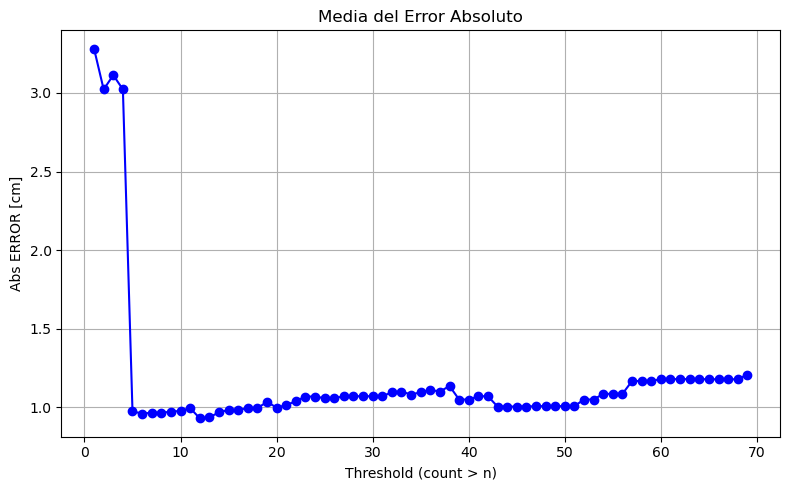

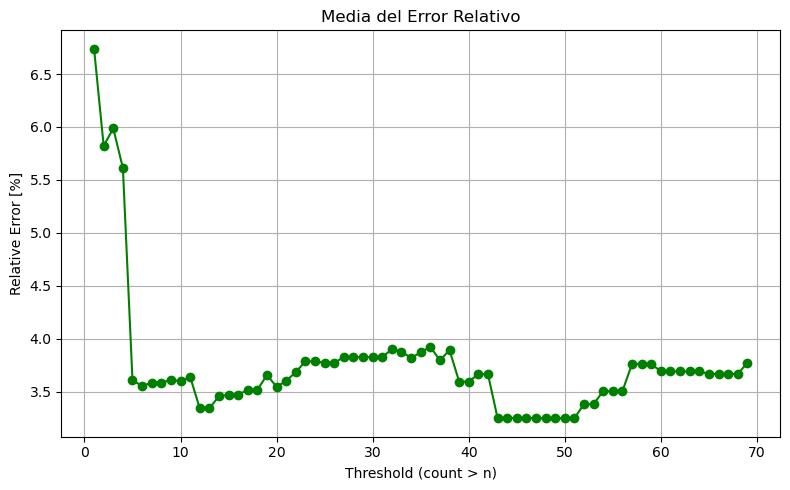

In [54]:
errores_abs=[]
errores_rel=[]

df = df_no_fake_fish
df = df_all_fish

x_range=range(1, df["count"].max() + 1)
x_range=range(1, 70)

for n_thr in  x_range:
# for n_thr in range(1, df["count"].max() + 1):
    df_tracked_temp = df[df["count"] > n_thr]

    media_error_abs = df_tracked_temp["AbsERROR [cm]"].mean()
    errores_abs.append(media_error_abs)

    media_error_rel = df_tracked_temp["Relative Error [%]"].abs().mean()
    errores_rel.append(media_error_rel)

# import matplotlib.pyplot as plt

# plt.plot(range(1, df["count"].max() + 1), errores_abs, label="Abs Error")
# plt.plot(range(1, df["count"].max() + 1), errores_rel, label="Rel Error")
# plt.xlabel("Threshold (count > n)")
# plt.ylabel("Error")
# plt.legend()
# plt.show()



# 1. Figura para el error absoluto
plt.figure(figsize=(8, 5))
plt.plot(x_range, errores_abs, marker='o', color='blue')
plt.title("Media del Error Absoluto")
plt.xlabel("Threshold (count > n)")
plt.ylabel("Abs ERROR [cm]")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Figura para el error relativo
plt.figure(figsize=(8, 5))
plt.plot(x_range, errores_rel, marker='o', color='green')
plt.title("Media del Error Relativo")
plt.xlabel("Threshold (count > n)")
plt.ylabel("Relative Error [%]")
plt.grid(True)
plt.tight_layout()
plt.show()

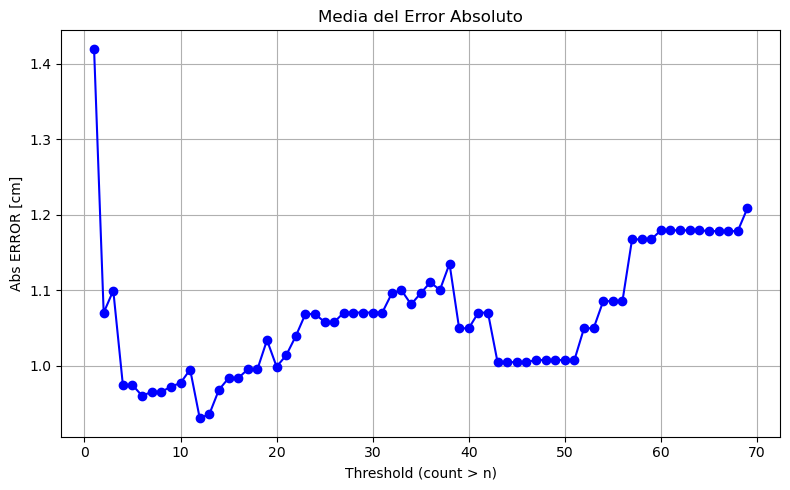

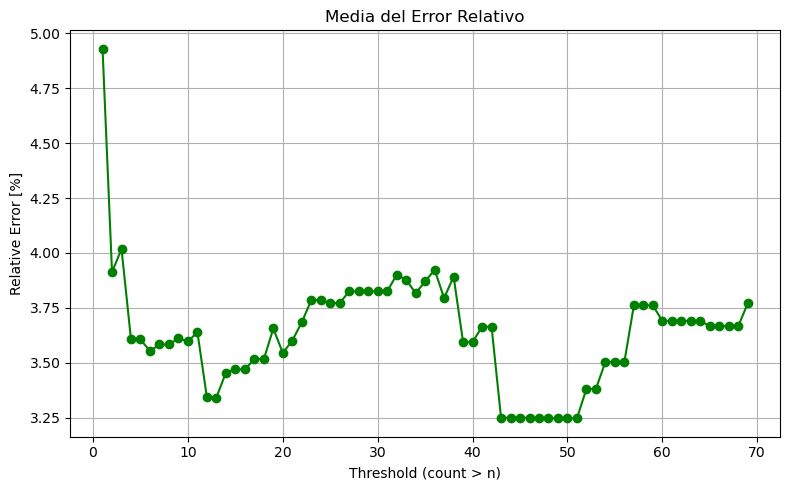

In [53]:
errores_abs=[]
errores_rel=[]

df = df_no_fake_fish
# df = df_all_fish

x_range=range(1, df["count"].max() + 1)
x_range=range(1, 70)

for n_thr in  x_range:
# for n_thr in range(1, df["count"].max() + 1):
    df_tracked_temp = df[df["count"] > n_thr]

    media_error_abs = df_tracked_temp["AbsERROR [cm]"].mean()
    errores_abs.append(media_error_abs)

    media_error_rel = df_tracked_temp["Relative Error [%]"].abs().mean()
    errores_rel.append(media_error_rel)

# import matplotlib.pyplot as plt

# plt.plot(range(1, df["count"].max() + 1), errores_abs, label="Abs Error")
# plt.plot(range(1, df["count"].max() + 1), errores_rel, label="Rel Error")
# plt.xlabel("Threshold (count > n)")
# plt.ylabel("Error")
# plt.legend()
# plt.show()



# 1. Figura para el error absoluto
plt.figure(figsize=(8, 5))
plt.plot(x_range, errores_abs, marker='o', color='blue')
plt.title("Media del Error Absoluto")
plt.xlabel("Threshold (count > n)")
plt.ylabel("Abs ERROR [cm]")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Figura para el error relativo
plt.figure(figsize=(8, 5))
plt.plot(x_range, errores_rel, marker='o', color='green')
plt.title("Media del Error Relativo")
plt.xlabel("Threshold (count > n)")
plt.ylabel("Relative Error [%]")
plt.grid(True)
plt.tight_layout()
plt.show()